In [6]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Period

In [7]:
iyear = 1960
fyear = 2019
variables = ['t2m','FLH','tcwv','ivt','vimd','tp','sf','rf', 'R']
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
domains = ["Tien Shan", "Pamir Alay", "Pamir", "Hindu Kush", "Karakoram", "Kunlun", "Spiti Lahaul", "Central Himalaya",
           "Bhutan", "Nyainqentangla", "Inner TP"]

In [8]:
path = '/bettik/PROJECTS/pr-regional-climate/bricej/paper/'

var_mean = {}

for var in variables:
    monthly_mean = pd.read_csv(f'{path}{var}_era5_monthly_mean_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
    var_mean[var] = monthly_mean

var_mean['t2m'].iloc[:, 1:] = var_mean['t2m'].iloc[:, 1:] - 273.15 # conversion K --> °C


In [9]:
var_mean['t2m']

,region,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,Tien Shan,-14.30143,-11.75350,-5.27988,1.67883,6.74650,10.94708,13.12830,12.35850,7.53300,0.15210,-7.28297,-12.26720
1,Pamir Alay,-11.11900,-9.01285,-3.91407,1.73860,6.09072,10.53655,13.19210,12.46720,8.09316,1.22220,-5.23585,-9.41703
2,Pamir,-19.24619,-16.46104,-11.51440,-6.35154,-1.84920,2.84432,7.35677,7.64996,3.05584,-5.87635,-13.87357,-17.85354
3,Hindu Kush,-11.51325,-9.28507,-4.56586,0.70132,5.45250,10.59442,14.10460,13.75247,9.65637,2.09945,-5.23890,-9.68140
4,Karakoram,-24.51003,-21.70963,-17.48191,-13.12095,-9.23774,-4.64286,1.36950,2.45303,-3.51636,-13.33692,-19.91130,-23.29287
5,Kunlun,-17.84913,-15.53574,-10.86387,-5.83690,-1.79243,2.63560,6.12142,5.78817,0.99618,-6.50352,-12.38395,-16.13645
6,Spiti Lahaul,-11.45524,-9.18630,-5.08723,-0.29180,4.18887,8.98376,12.58676,12.73382,8.96905,1.78118,-4.96170,-9.49167
7,Central Himalaya,-3.59724,-1.96552,1.80566,6.42916,10.16696,13.42010,14.30477,14.04360,12.14016,7.22582,2.51013,-1.16663
8,Bhutan,-3.11518,-1.24476,1.90527,5.51500,9.08720,12.28470,13.03222,12.89608,11.37280,7.03200,1.90580,-1.41346
9,Nyainqentangla,-12.59266,-10.00135,-6.54500,-2.17695,2.68890,7.27810,9.17925,9.00808,6.72230,0.15500,-8.10320,-11.82212


# Plot

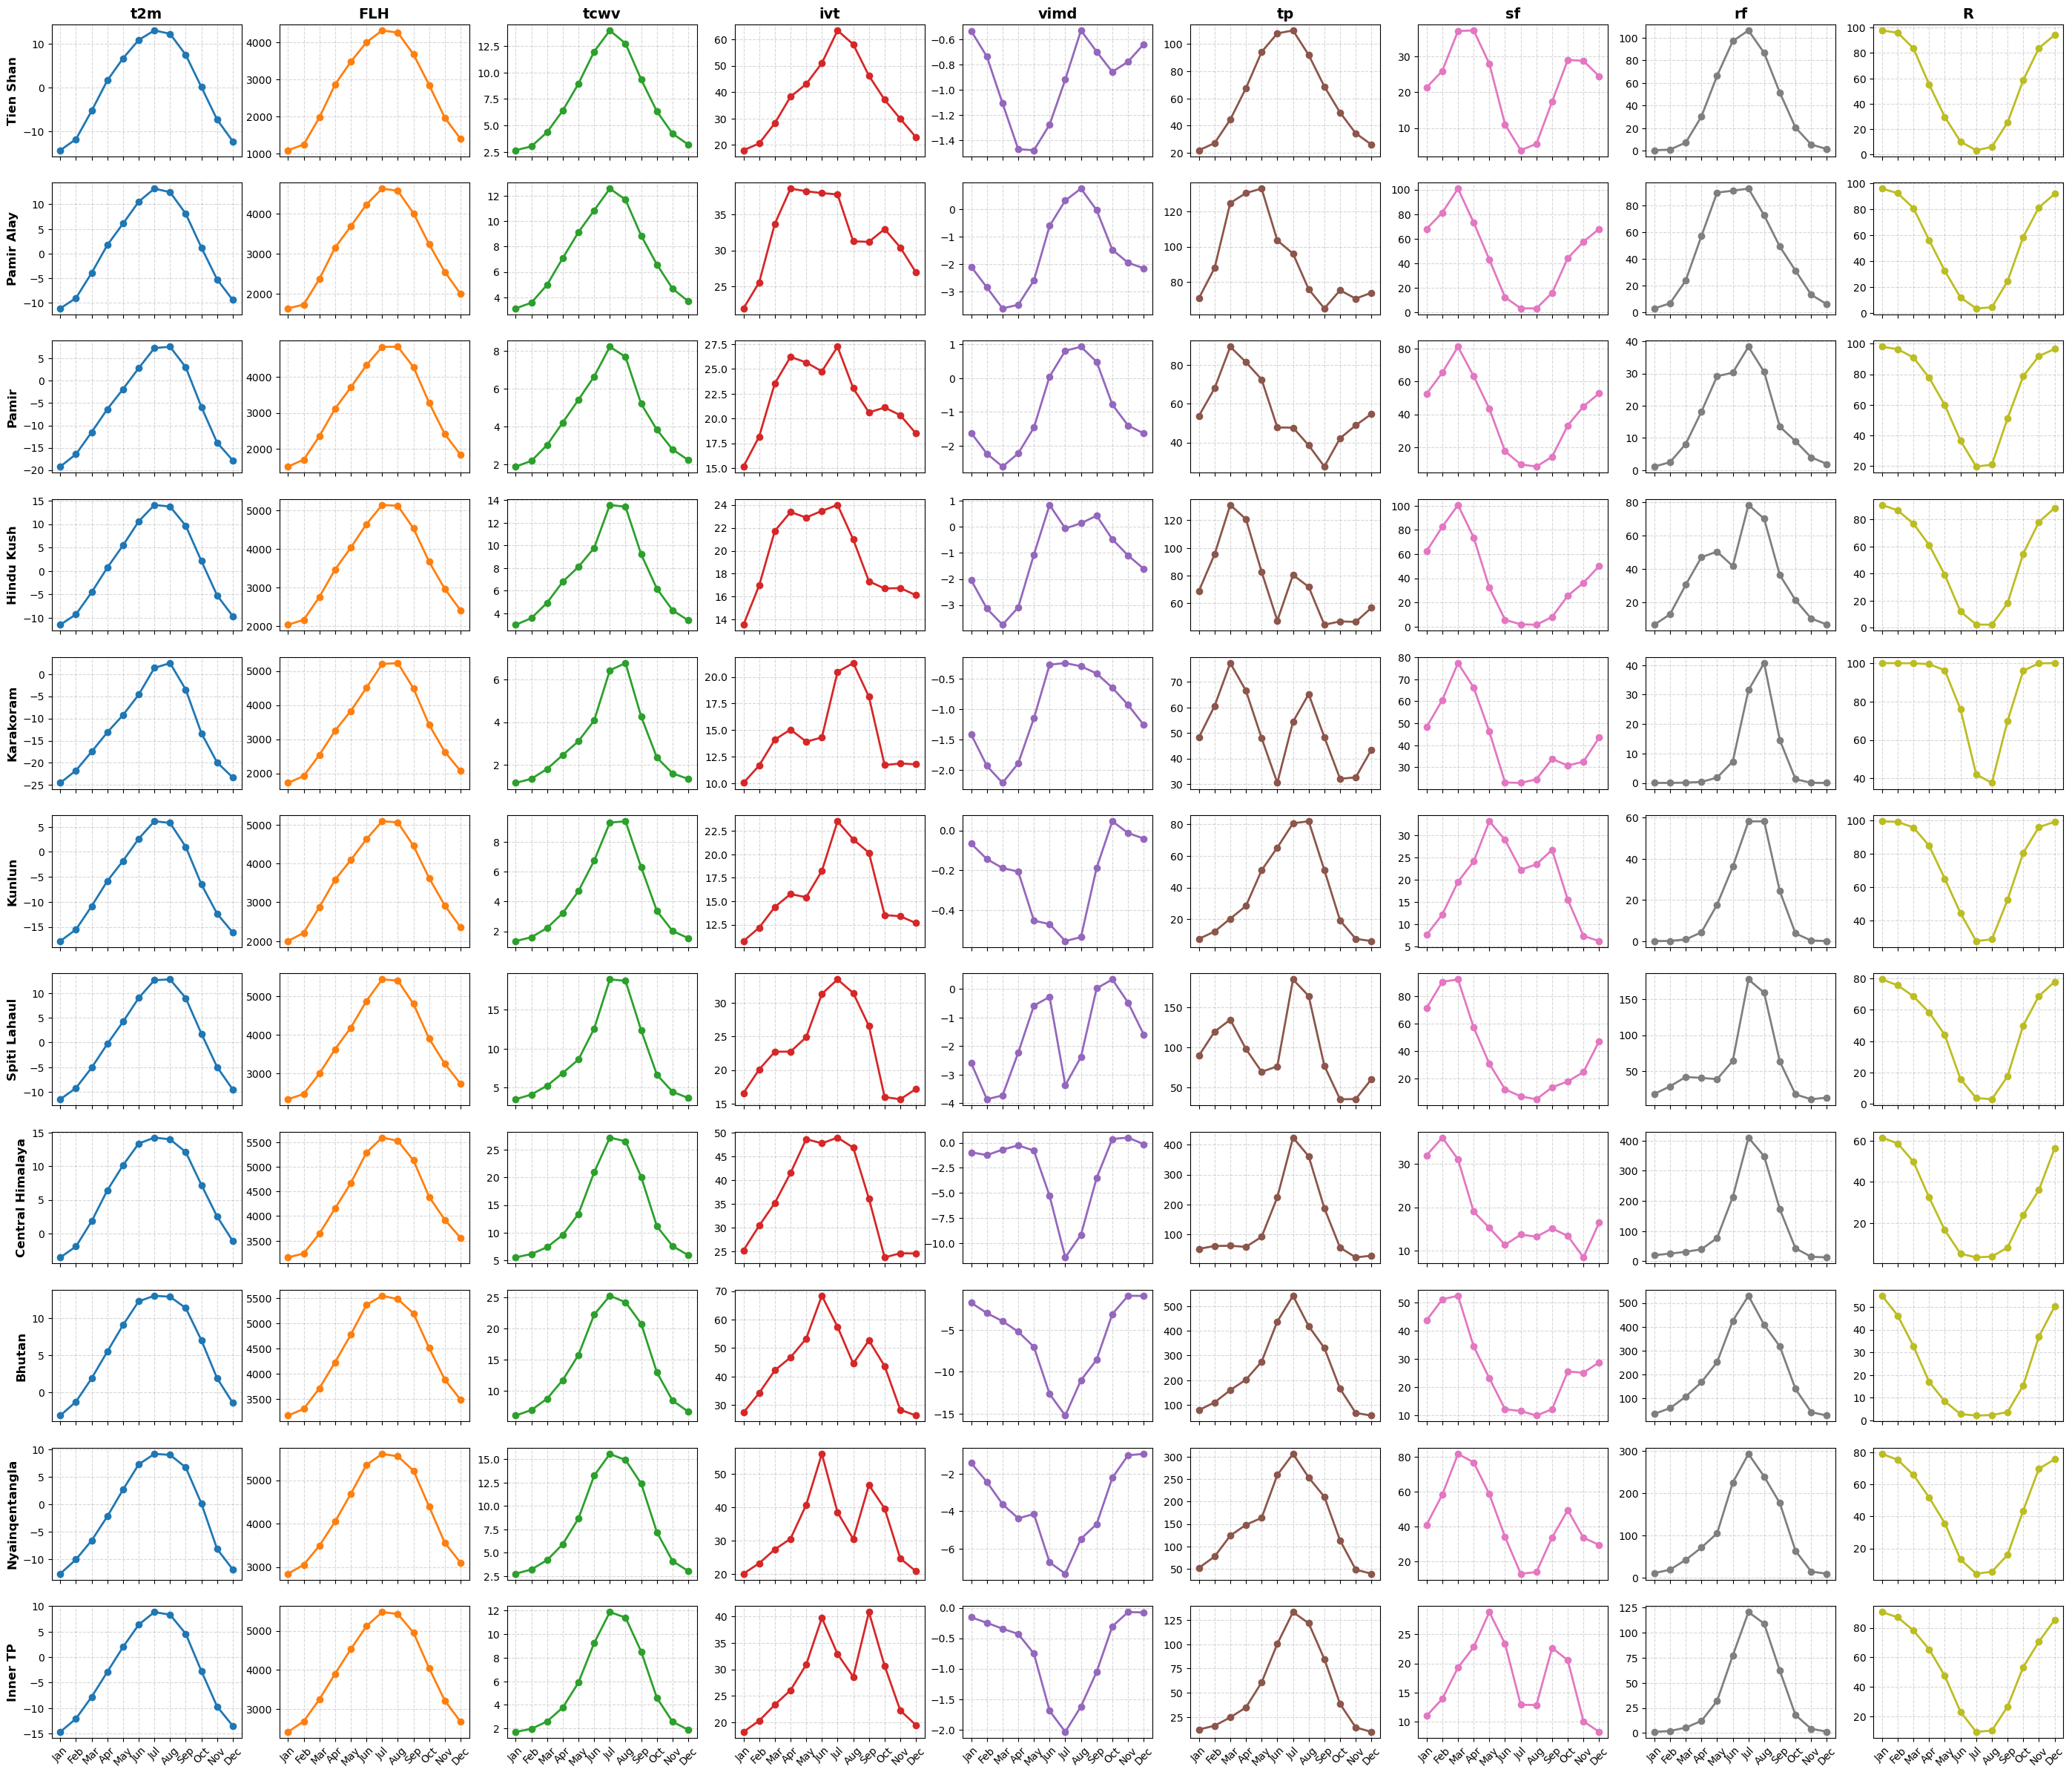

In [10]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray',
    'tab:olive'
]

fig, axes = plt.subplots(11, 9, figsize=(35, 30))

# mettre region en index pour la boucle
dfs = {v: var_mean[v].set_index("region") for v in variables}

for i, dom in enumerate(domains): # ligne
    for j, var in enumerate(variables): # colonne
        
        ax = axes[i,j]
        color = colors[j]
        
        mean = dfs[var].loc[dom].values
        
        # ligne pointillée pour relier les trends
        ax.plot(
            range(1, 13),
            mean,
            linestyle='-',
            marker='o',
            linewidth=2,
            color=color
        )

        # y lim pour chaque colonne 
        #ax.set_ylim(ylims[var])
        
        # titre des variables
        if i == 0:
            ax.set_title(var, fontsize=14, weight='bold')

        # titre des régions
        if j == 0:
            ax.set_ylabel(dom, fontsize=12, weight='bold')

        # labe des mois que sur la dernière ligne
        ax.set_xticks(range(1, 13))
        if i == len(domains) - 1:
            ax.set_xticklabels(months, rotation=45, fontsize=10)
        else:
            ax.tick_params(labelbottom=False)

        # yticks & labelticks partout
        ax.tick_params(axis='y',labelleft=True)
        
        ax.grid(True, linestyle='--', alpha=0.5)

plt.show()